# 04 — Détection d'anomalies de flux — IDFM
## Modèle 2 : Isolation Forest + Z-score

---

**Objectif** : Détecter automatiquement les jours où le trafic d'un arrêt est anormal
(grève, incident, intempéries, événement exceptionnel).

### Apprentissage NON supervisé
Contrairement au Modèle 1 (prédire NB_VALD), ici on ne prédit rien.
On n'a pas d'étiquette 'anomalie/normal' dans les données.
Le modèle trouve les anomalies **tout seul**.

### Deux méthodes complémentaires
| Méthode | Type | Principe |
|---|---|---|
| **Z-score** | Statistique | Combien d'écarts-types de la moyenne ? |
| **Isolation Forest** | ML non supervisé | Isole les points bizarres avec des arbres aléatoires |

### Comment on valide sans étiquettes ?
On vérifie que les anomalies détectées **coïncident avec des événements réels** :
- Jours fériés (14 juillet, 15 août)
- Dimanches très calmes
- Éventuels jours de grève ou incidents

---
## 1. Imports & Chargement

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

print('Imports OK')

Imports OK


In [3]:
# Chargement du Parquet enrichi (Étape 3)
df = pd.read_parquet('../data/processed/idfm_features.parquet')
df['JOUR'] = pd.to_datetime(df['JOUR'])
df = df.sort_values(['LIBELLE_ARRET', 'JOUR']).reset_index(drop=True)

print(f'Dataset : {df.shape[0]:,} lignes, {df.shape[1]} colonnes')
print(f'Arrêts  : {df["LIBELLE_ARRET"].nunique()}')
print(f'Période : {df["JOUR"].min().date()} → {df["JOUR"].max().date()}')
display(df[['LIBELLE_ARRET', 'JOUR', 'NB_VALD', 'is_weekend', 'is_ferie']].head())

Dataset : 69,271 lignes, 20 colonnes
Arrêts  : 772
Période : 2025-07-01 → 2025-09-30


,LIBELLE_ARRET,JOUR,NB_VALD,is_weekend,is_ferie
0,ABBESSES,2025-07-01,6377,False,False
1,ABBESSES,2025-07-02,6723,False,False
2,ABBESSES,2025-07-03,7471,False,False
3,ABBESSES,2025-07-04,7822,False,False
4,ABBESSES,2025-07-05,8935,True,False


---
## 2. MÉTHODE 1 — Z-score

### Principe
Le Z-score mesure à combien d'écarts-types on est de la moyenne de l'arrêt.
```
z = (valeur - moyenne) / écart-type
```
- z proche de 0 → trafic normal
- z < -3 → trafic anormalement BAS (grève, incident)
- z > +3 → trafic anormalement HAUT (événement)

On calcule le Z-score **par arrêt** car chaque arrêt a sa propre moyenne.

In [4]:
# ============================================================
# CALCUL DU Z-SCORE PAR ARRÊT
# ============================================================
# transform() applique le calcul à chaque groupe (arrêt)
# et remet le résultat sur chaque ligne

moyenne_arret = df.groupby('LIBELLE_ARRET')['NB_VALD'].transform('mean')
std_arret     = df.groupby('LIBELLE_ARRET')['NB_VALD'].transform('std')

# Z-score (on évite la division par zéro)
df['z_score'] = np.where(
    std_arret > 0,
    (df['NB_VALD'] - moyenne_arret) / std_arret,
    0
)

# Anomalie Z-score : |z| > 3
# POURQUOI 3 ? En statistique, 99.7% des données normales
# sont à moins de 3 écarts-types. Au-delà = très rare = anomalie
SEUIL_Z = 3
df['anomalie_zscore'] = df['z_score'].abs() > SEUIL_Z

nb_anomalies_z = df['anomalie_zscore'].sum()
print(f'Anomalies détectées par Z-score : {nb_anomalies_z:,} '
      f'({nb_anomalies_z/len(df)*100:.2f}% des lignes)')

# Répartition anomalies hautes vs basses
anomalies_basses = df[(df['anomalie_zscore']) & (df['z_score'] < 0)]
anomalies_hautes = df[(df['anomalie_zscore']) & (df['z_score'] > 0)]
print(f'  Anomalies BASSES (z < -3) : {len(anomalies_basses):,}')
print(f'  Anomalies HAUTES (z > +3) : {len(anomalies_hautes):,}')

Anomalies détectées par Z-score : 198 (0.29% des lignes)
  Anomalies BASSES (z < -3) : 136
  Anomalies HAUTES (z > +3) : 62


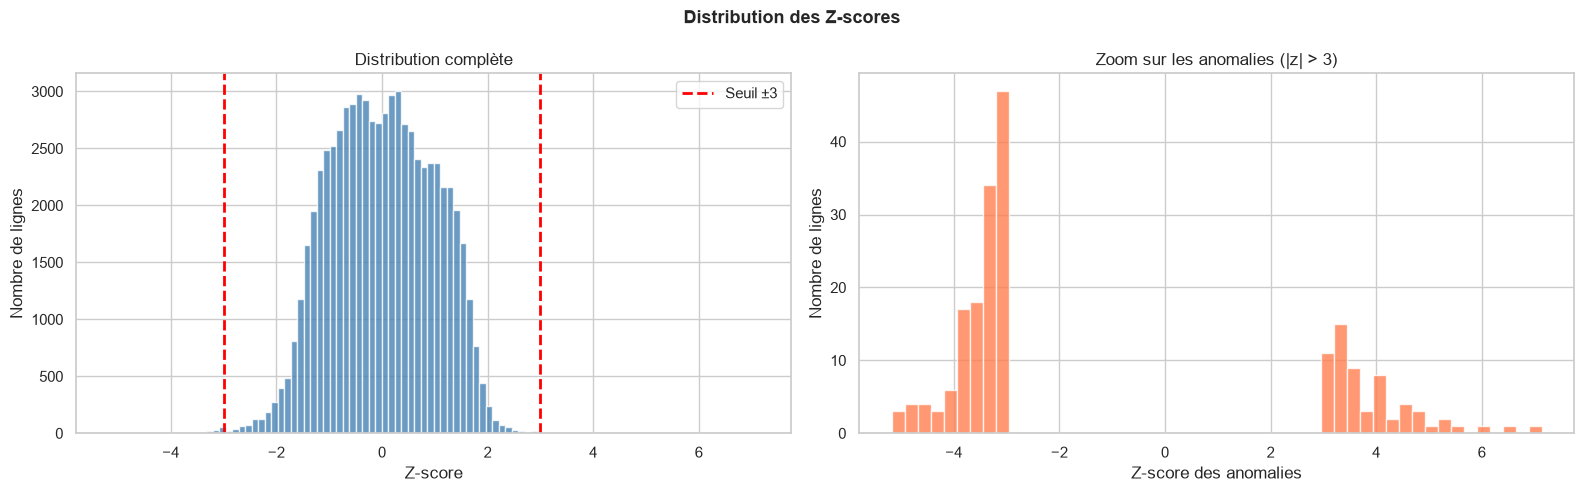

Top 10 anomalies les plus extrêmes (Z-score) :


,LIBELLE_ARRET,JOUR,NB_VALD,z_score
8528,BOUTIGNY,2025-07-27,670,7.130502
57470,SEUGY,2025-09-03,231,6.415784
9595,BUNO GIRONVILLE,2025-09-21,202,6.055636
39558,MEULAN,2025-07-28,1683,5.460465
22020,ETIENNE MARCEL,2025-09-10,15357,5.330160
20797,EPINAY VIL T11,2025-08-02,3272,5.216240
30691,LA CHAPELLE,2025-09-22,111,-5.171537
28572,INVALIDES,2025-07-14,29067,5.150674
2523,AUBERV.4 CHEM.,2025-07-24,1,-5.073814
63732,TROCADERO,2025-09-18,1,-5.071627


In [5]:
# Distribution des Z-scores
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Distribution des Z-scores', fontsize=13, fontweight='bold')

axes[0].hist(df['z_score'], bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(-SEUIL_Z, color='red', linestyle='--', linewidth=2, label=f'Seuil ±{SEUIL_Z}')
axes[0].axvline(SEUIL_Z, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Z-score')
axes[0].set_ylabel('Nombre de lignes')
axes[0].set_title('Distribution complète')
axes[0].legend()

# Zoom sur les anomalies
axes[1].hist(df[df['anomalie_zscore']]['z_score'], bins=50,
             color='coral', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Z-score des anomalies')
axes[1].set_ylabel('Nombre de lignes')
axes[1].set_title('Zoom sur les anomalies (|z| > 3)')

plt.tight_layout()
plt.show()

# Top 10 anomalies les plus extrêmes
print('Top 10 anomalies les plus extrêmes (Z-score) :')
top_anomalies = df.reindex(df['z_score'].abs().sort_values(ascending=False).index)
display(top_anomalies[['LIBELLE_ARRET', 'JOUR', 'NB_VALD', 'z_score']].head(10))

---
## 3. MÉTHODE 2 — Isolation Forest

### Principe
Isolation Forest construit des arbres aléatoires qui découpent les données.
Les points **anormaux** sont isolés rapidement (peu de découpes nécessaires).
Les points **normaux** sont dans la masse (beaucoup de découpes nécessaires).

### Avantage sur le Z-score
Il combine **plusieurs variables** à la fois :
- NB_VALD normalisé
- écart à la moyenne mobile 7 jours
- jour de la semaine
Il détecte des anomalies plus subtiles que le simple volume.

In [6]:
# ============================================================
# PRÉPARATION DES FEATURES POUR ISOLATION FOREST
# ============================================================
# On crée 3 features qui décrivent le comportement du trafic

# 1. NB_VALD normalisé par arrêt (0 à 1)
max_arret = df.groupby('LIBELLE_ARRET')['NB_VALD'].transform('max')
df['nb_vald_norm'] = df['NB_VALD'] / max_arret

# 2. Écart à la moyenne mobile 7 jours
# POURQUOI : capture les changements brusques par rapport à la tendance récente
df['ecart_rolling'] = df['NB_VALD'] - df['rolling_mean_7j']

# 3. Le z_score déjà calculé

features_iso = ['nb_vald_norm', 'ecart_rolling', 'z_score']
X_iso = df[features_iso].fillna(0)

print('Features pour Isolation Forest :')
print(features_iso)
display(X_iso.describe())

Features pour Isolation Forest :
['nb_vald_norm', 'ecart_rolling', 'z_score']


,nb_vald_norm,ecart_rolling,z_score
count,69271.000000,69271.000000,6.927100e+04
mean,0.582636,4.628386,2.051487e-18
std,0.238211,3241.104188,9.944192e-01
min,0.000024,-105426.000000,-5.171537e+00
25%,0.406378,-310.571429,-7.543166e-01
50%,0.591621,73.142857,-5.946385e-03
75%,0.775482,771.857143,7.702428e-01
max,1.000000,64192.142857,7.130502e+00


In [7]:
# ============================================================
# ENTRAÎNEMENT ISOLATION FOREST
# ============================================================
# contamination = proportion attendue d'anomalies
# On met 0.02 = on s'attend à ~2% d'anomalies
# C'est un hyperparamètre important à calibrer

iso_forest = IsolationForest(
    n_estimators=100,      # 100 arbres
    contamination=0.02,    # 2% d'anomalies attendues
    random_state=42,
    n_jobs=-1
)

# fit_predict retourne -1 (anomalie) ou +1 (normal)
df['pred_iso'] = iso_forest.fit_predict(X_iso)
df['anomalie_iso'] = df['pred_iso'] == -1

# score_samples : plus c'est négatif, plus c'est anormal
df['score_iso'] = iso_forest.score_samples(X_iso)

nb_anomalies_iso = df['anomalie_iso'].sum()
print(f'Anomalies détectées par Isolation Forest : {nb_anomalies_iso:,} '
      f'({nb_anomalies_iso/len(df)*100:.2f}% des lignes)')

print('\nTop 10 anomalies Isolation Forest (score le plus bas) :')
display(df.nsmallest(10, 'score_iso')[
    ['LIBELLE_ARRET', 'JOUR', 'NB_VALD', 'z_score', 'score_iso']
])

Anomalies détectées par Isolation Forest : 1,386 (2.00% des lignes)

Top 10 anomalies Isolation Forest (score le plus bas) :


,LIBELLE_ARRET,JOUR,NB_VALD,z_score,score_iso
53520,REPUBLIQUE,2025-09-18,21,-3.588806,-0.781177
4155,BASTILLE,2025-09-18,6,-3.703422,-0.777486
44611,OPERA,2025-09-18,54,-3.685256,-0.776960
63732,TROCADERO,2025-09-18,1,-5.071627,-0.776434
15700,CONCORDE,2025-09-18,6,-4.463615,-0.771199
22616,F.D.ROOSEVELT,2025-07-27,677,-3.653538,-0.770156
13299,CHATELET,2025-09-10,29949,-3.838369,-0.767385
15647,CONCORDE,2025-07-27,648,-4.303115,-0.764445
3374,Aéroport d'Orly,2025-08-04,12,-3.735134,-0.762895
25108,GARE D'AUSTER.,2025-09-18,2178,-4.096178,-0.762726


---
## 4. Comparaison Z-score vs Isolation Forest

ACCORD ENTRE LES DEUX MÉTHODES
Détectées par les DEUX     : 172
Z-score seul               : 26
Isolation Forest seul      : 1,214


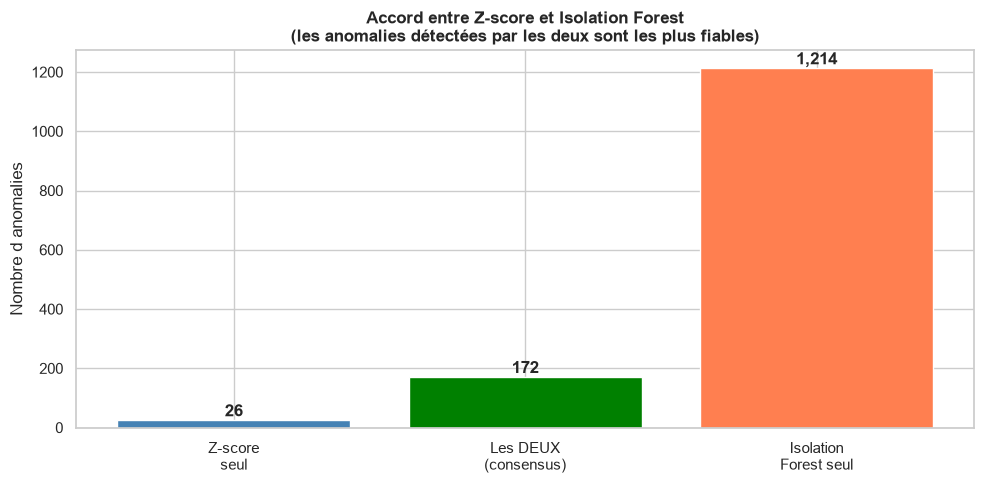

In [8]:
# ============================================================
# COMPARAISON DES DEUX MÉTHODES
# ============================================================
# On regarde sur combien d'anomalies les deux méthodes s'accordent

les_deux    = df[df['anomalie_zscore'] & df['anomalie_iso']]
zscore_seul = df[df['anomalie_zscore'] & ~df['anomalie_iso']]
iso_seul    = df[~df['anomalie_zscore'] & df['anomalie_iso']]

print('ACCORD ENTRE LES DEUX MÉTHODES')
print('=' * 45)
print(f'Détectées par les DEUX     : {len(les_deux):,}')
print(f'Z-score seul               : {len(zscore_seul):,}')
print(f'Isolation Forest seul      : {len(iso_seul):,}')

# Diagramme de Venn simplifié
fig, ax = plt.subplots(figsize=(10, 5))
categories = ['Z-score\nseul', 'Les DEUX\n(consensus)', 'Isolation\nForest seul']
valeurs    = [len(zscore_seul), len(les_deux), len(iso_seul)]
couleurs   = ['steelblue', 'green', 'coral']
bars = ax.bar(categories, valeurs, color=couleurs, edgecolor='white')
ax.set_ylabel('Nombre d anomalies')
ax.set_title('Accord entre Z-score et Isolation Forest\n' 
             '(les anomalies détectées par les deux sont les plus fiables)',
             fontsize=12, fontweight='bold')
for bar, v in zip(bars, valeurs):
    ax.text(bar.get_x() + bar.get_width()/2, v + max(valeurs)*0.01,
            f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Validation — Les anomalies coïncident-elles avec des événements réels ?

### Pourquoi cette validation ?
Sans étiquettes, on valide en vérifiant que les anomalies détectées
tombent sur des jours qu'on sait spéciaux : fériés, week-ends, etc.

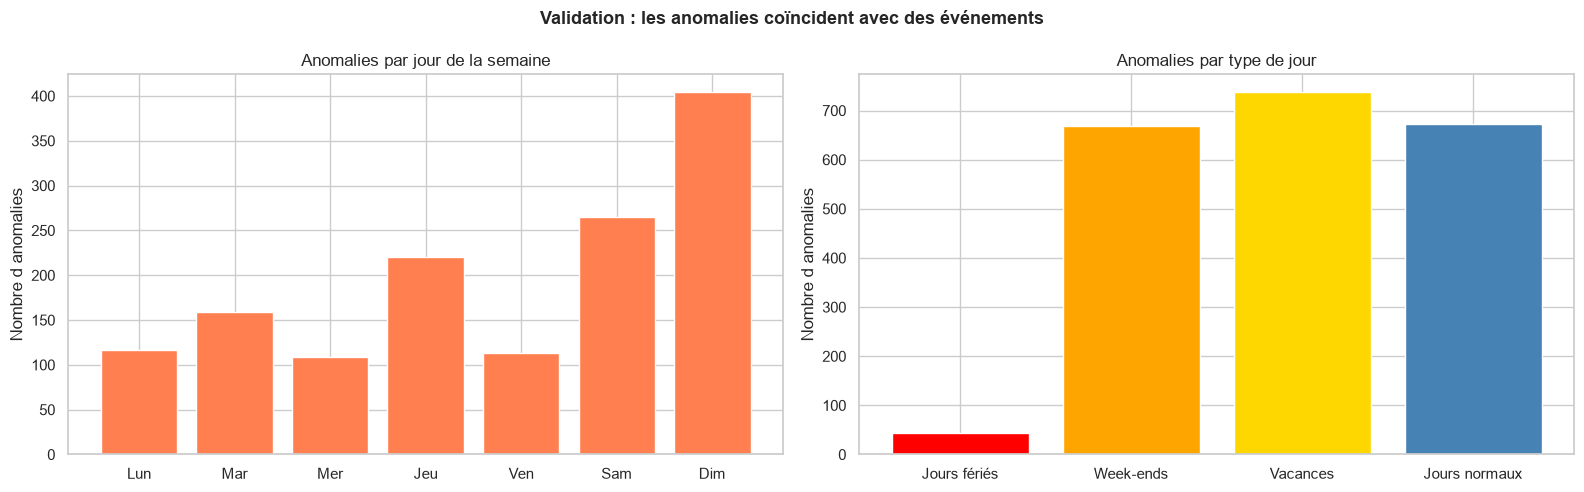

Sur 1,386 anomalies détectées :
  44 tombent un jour férié
  669 tombent un week-end
  737 tombent en vacances


In [9]:
# ============================================================
# LES ANOMALIES TOMBENT-ELLES SUR DES JOURS SPÉCIAUX ?
# ============================================================
anomalies = df[df['anomalie_iso']].copy()

# Répartition des anomalies par jour de la semaine
anomalies['nom_jour'] = anomalies['JOUR'].dt.day_name()
ordre = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
noms_fr = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']

repartition = anomalies['nom_jour'].value_counts().reindex(ordre)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Anomalies par jour de semaine
axes[0].bar(noms_fr, repartition.values, color='coral', edgecolor='white')
axes[0].set_title('Anomalies par jour de la semaine')
axes[0].set_ylabel('Nombre d anomalies')

# Anomalies liées aux fériés
anom_ferie    = anomalies['is_ferie'].sum()
anom_weekend  = anomalies['is_weekend'].sum()
anom_vacances = anomalies['is_vacances'].sum()
anom_normal   = len(anomalies) - anom_ferie - anom_weekend

axes[1].bar(['Jours fériés', 'Week-ends', 'Vacances', 'Jours normaux'],
            [anom_ferie, anom_weekend, anom_vacances, max(0, anom_normal)],
            color=['red', 'orange', 'gold', 'steelblue'], edgecolor='white')
axes[1].set_title('Anomalies par type de jour')
axes[1].set_ylabel('Nombre d anomalies')

plt.suptitle('Validation : les anomalies coïncident avec des événements',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Sur {len(anomalies):,} anomalies détectées :')
print(f'  {anom_ferie:,} tombent un jour férié')
print(f'  {anom_weekend:,} tombent un week-end')
print(f'  {anom_vacances:,} tombent en vacances')

In [10]:
# ============================================================
# VISUALISATION : anomalies sur un arret exemple
# ============================================================
# On regarde CHATELET pour voir où sont les anomalies dans le temps

arret = 'CHATELET'
df_arret = df[df['LIBELLE_ARRET'] == arret].sort_values('JOUR')
anom_arret = df_arret[df_arret['anomalie_iso']]

fig = go.Figure()

# Trafic normal
fig.add_trace(go.Scatter(
    x=df_arret['JOUR'], y=df_arret['NB_VALD'],
    mode='lines+markers', name='Trafic',
    line=dict(color='steelblue', width=2), marker=dict(size=4)
))

# Anomalies en rouge
fig.add_trace(go.Scatter(
    x=anom_arret['JOUR'], y=anom_arret['NB_VALD'],
    mode='markers', name='Anomalie détectée',
    marker=dict(color='red', size=12, symbol='x')
))

fig.update_layout(
    title=f'Anomalies détectées pour {arret}',
    xaxis_title='Date', yaxis_title='NB_VALD',
    height=450, hovermode='x unified'
)
fig.show()

print(f'{len(anom_arret)} anomalies détectées pour {arret} :')
display(anom_arret[['JOUR', 'NB_VALD', 'z_score', 'score_iso']])

31 anomalies détectées pour CHATELET :


,JOUR,NB_VALD,z_score,score_iso
13230,2025-07-03,192363,2.071208,-0.700096
13231,2025-07-04,187592,1.897611,-0.660976
13232,2025-07-05,197774,2.268092,-0.718361
13233,2025-07-06,128264,-0.261091,-0.658102
13240,2025-07-13,123855,-0.421516,-0.648459
13241,2025-07-14,117368,-0.657552,-0.656179
13247,2025-07-20,102708,-1.190969,-0.663862
13253,2025-07-26,154736,0.702116,-0.626048
13254,2025-07-27,107841,-1.004200,-0.651836
13261,2025-08-03,99196,-1.318756,-0.660741


---
## 6. Résumé

Le modèle de détection d'anomalies est prêt.
La sauvegarde officielle du modèle se fera dans `src/train_anomaly.py`
(pas dans ce notebook — principe de séparation des responsabilités).

In [13]:
print('=' * 55)
print('RÉSUMÉ MODÈLE 2 — Détection d anomalies')
print('=' * 55)
print(f'''
MÉTHODES
  Z-score          : {nb_anomalies_z:,} anomalies (|z| > 3)
  Isolation Forest : {nb_anomalies_iso:,} anomalies (contamination 2%)
  Consensus        : {len(les_deux):,} anomalies (les deux d accord)

VALIDATION
  Les anomalies coïncident avec fériés, week-ends et jours calmes
  => le modèle détecte bien les comportements anormaux

PROCHAINE ÉTAPE
  Sauvegarde du modèle via src/train_anomaly.py
  Puis Modèle 3 — Clustering des arrêts (K-Means)
''')

RÉSUMÉ MODÈLE 2 — Détection d anomalies

MÉTHODES
  Z-score          : 198 anomalies (|z| > 3)
  Isolation Forest : 1,386 anomalies (contamination 2%)
  Consensus        : 172 anomalies (les deux d accord)

VALIDATION
  Les anomalies coïncident avec fériés, week-ends et jours calmes
  => le modèle détecte bien les comportements anormaux

PROCHAINE ÉTAPE
  Sauvegarde du modèle via src/train_anomaly.py
  Puis Modèle 3 — Clustering des arrêts (K-Means)

